In [1]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp
from lineage import LineageMap
sql1 = """
SELECT
    ranked_customers.customer_id,
    ranked_customers.first_name,
    ranked_customers.last_name,
    ranked_customers.total_spent
FROM (
    SELECT
        c.customer_id,
        c.first_name,
        c.last_name,
        SUM(o.total_amount) AS total_spent
    FROM customers c
    INNER JOIN orders o
        ON o.customer_id = c.customer_id
    WHERE o.status = 'COMPLETED'
    GROUP BY
        c.customer_id,
        c.first_name,
        c.last_name
) AS ranked_customers
WHERE ranked_customers.total_spent > (
    SELECT AVG(o2.total_amount)
    FROM orders o2
    WHERE o2.status = 'COMPLETED'
)
ORDER BY ranked_customers.total_spent DESC
"""

sql2 = """
CREATE TABLE customers AS SELECT
customer_id, first_name, last_name
FROM base.customers;
"""

sql3 = """
create table base.customers(
customer_id int,
first_name varchar(255),
last_name varchar(255)
)
"""

sql4 = """
SELECT
customer_id, first_name, last_name
FROM base.customers;
"""

l = LineageMap()
l.parse_sql(sql2, file_name="temp2")
# l._parse_scope(sql2)
l.parse_sql(sql4, file_name="temp4")
l.parse_sql(sql3, file_name="temp3")


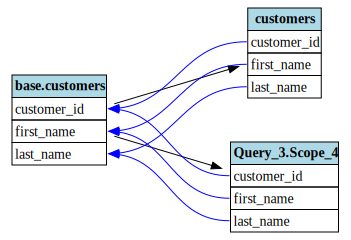

In [2]:
l.visualize()

In [5]:
for n in l.visited_scopes.values():
    print(n.columns)

{'customer_id': <lineage.ColumnNode object at 0x10e301390>, 'first_name': <lineage.ColumnNode object at 0x10e32e6d0>, 'last_name': <lineage.ColumnNode object at 0x10e32f3d0>}
{}


In [4]:
l._parse_column(l.original_scope.expression.selects[0]).get_source_columns()

[('customers', 'customer_id')]

In [16]:
l.original_scope.expression.selects

[Alias(
   this=Column(
     this=Identifier(this='customer_id', quoted=True),
     table=Identifier(this='customers', quoted=True)),
   alias=Identifier(this='customer_id', quoted=True)),
 Alias(
   this=Column(
     this=Identifier(this='first_name', quoted=True),
     table=Identifier(this='customers', quoted=True)),
   alias=Identifier(this='first_name', quoted=True)),
 Alias(
   this=Column(
     this=Identifier(this='last_name', quoted=True),
     table=Identifier(this='customers', quoted=True)),
   alias=Identifier(this='last_name', quoted=True))]

In [11]:
ast = qualify(parse_one(sql2))

In [8]:
scope = build_scope(ast)

In [9]:
scope

Scope<SELECT customer_id, first_name, last_name FROM base.customers>

In [12]:
print(ast)

CREATE TABLE "customers" AS SELECT "customers"."customer_id" AS "customer_id", "customers"."first_name" AS "first_name", "customers"."last_name" AS "last_name" FROM "base"."customers" AS "customers"
